In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [2]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

# if the API does a "ReadTimeout", it means the API was asleep and if you call it a minute later it will be back online
# I will put it behind an always-on API when more people are paying for it. Currently, I am the only one who seems to be
# using it, so I do not mind. :)

Loaded as API: https://verdantintel-verdanteye.hf.space


# Helper Function

In [3]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

# Searching for Data

In [4]:
question = 'what has been seen in the last 24 hours?'

answer = ask_api(client, question)
len(answer)

5779

In [5]:
answer[0]

{'claim': 'Nine deportees from the US have arrived in Sierra.',
 'url': 'https://news.yahoo.com/news/articles/9-deportees-us-arrive-sierra-172300803.html',
 'domain': 'news.yahoo.com',
 'url_domain': 'news.yahoo.com',
 'date_added': '2026-05-20 18:21:36'}

In [6]:
df = pd.DataFrame(answer)
df['date_added'] = pd.to_datetime(df['date_added'], utc=True)
df['date_added'] = df['date_added'].dt.tz_convert('America/Los_Angeles') # put into my timezone
df.sort_values('date_added', ascending=False, inplace=True)


drop_terms = [
    'news article', 'news topic', 'status update', 'event', 'ticket', 'not identified', 
    'not enough information', 'news update', 'no specific claim', 'no claim', 'unspecified news',
    'article related to', 'claim related to', 'claim not specified', 'recent news post', 'a specific report',
    'lacks specific claim', 'unclear claim', 'unspecified incident', 'no claims available',
    'news story', 'news report', 'news post', 'news item', 'current news', 'unknown claim', 'uncertain claim',
    'video clip is available', 'no clear claim', 'claim not discernible', 'not specified', 'unspecified', 
    'claim is unclear', 'news related', 'specific news', 'unspecified content', 'report related to a',
    'Claim not explicit'
]

pattern = '|'.join(drop_terms)

df = df[~df['claim'].str.contains(pattern, case=False, na=False)]


df.head()

,claim,url,domain,url_domain,date_added
0,Nine deportees from the US have arrived in Sie...,https://news.yahoo.com/news/articles/9-deporte...,news.yahoo.com,news.yahoo.com,2026-05-20 11:21:36-07:00
1,Victims of the San Diego mosque shooting are b...,https://houstonpublicmedia.org/npr/2026/05/20/...,houstonpublicmedia.org,houstonpublicmedia.org,2026-05-20 11:21:35-07:00
4,Information regarding tax issues related to th...,https://newsday.com/long-island/towns/long-isl...,newsday.com,newsday.com,2026-05-20 11:21:10-07:00
3,Discussion about Dennis Arfa and Billy Joel,https://newsday.com/entertainment/music/dennis...,newsday.com,newsday.com,2026-05-20 11:21:10-07:00
5,A trial is taking place involving individuals ...,https://independent.co.uk/news/uk/crime/pouria...,independent.co.uk,independent.co.uk,2026-05-20 11:20:41-07:00


In [7]:
df.tail() # 24 hours

,claim,url,domain,url_domain,date_added
5774,A man was bitten by a dog in Wellin Lane.,https://westbridgfordwire.com/edwalton-image-s...,westbridgfordwire.com/events,westbridgfordwire.com,2026-05-19 11:25:43-07:00
5775,"A cyclist was found injured, prompting road cl...",https://westbridgfordwire.com/police-close-not...,westbridgfordwire.com/events,westbridgfordwire.com,2026-05-19 11:25:43-07:00
5776,Details on a landmark forced marriage case in ...,https://westbridgfordwire.com/police-reveal-ho...,westbridgfordwire.com/events,westbridgfordwire.com,2026-05-19 11:25:43-07:00
5777,Three individuals have been charged with posse...,https://westbridgfordwire.com/trio-charged-aft...,westbridgfordwire.com/events,westbridgfordwire.com,2026-05-19 11:25:43-07:00
5778,A West Bridgford mother celebrates eight years...,https://westbridgfordwire.com/west-bridgford-m...,westbridgfordwire.com/events,westbridgfordwire.com,2026-05-19 11:25:43-07:00


In [8]:
df.shape

(3979, 5)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [9]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [10]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [11]:
df.head()

,claim,url,domain,url_domain,date_added
0,Nine deportees from the US have arrived in Sie...,https://news.yahoo.com/news/articles/9-deporte...,news.yahoo.com,news.yahoo.com,2026-05-20 11:21:36-07:00
1,Victims of the San Diego mosque shooting are b...,https://houstonpublicmedia.org/npr/2026/05/20/...,houstonpublicmedia.org,houstonpublicmedia.org,2026-05-20 11:21:35-07:00
4,Information regarding tax issues related to th...,https://newsday.com/long-island/towns/long-isl...,newsday.com,newsday.com,2026-05-20 11:21:10-07:00
3,Discussion about Dennis Arfa and Billy Joel,https://newsday.com/entertainment/music/dennis...,newsday.com,newsday.com,2026-05-20 11:21:10-07:00
5,A trial is taking place involving individuals ...,https://independent.co.uk/news/uk/crime/pouria...,independent.co.uk,independent.co.uk,2026-05-20 11:20:41-07:00


In [12]:
df['cluster'] = cluster_text(df['claim'], similarity_threshold=0.4) # reducing to capture broader topics
df.head()

,claim,url,domain,url_domain,date_added,cluster
0,Nine deportees from the US have arrived in Sie...,https://news.yahoo.com/news/articles/9-deporte...,news.yahoo.com,news.yahoo.com,2026-05-20 11:21:36-07:00,0
1,Victims of the San Diego mosque shooting are b...,https://houstonpublicmedia.org/npr/2026/05/20/...,houstonpublicmedia.org,houstonpublicmedia.org,2026-05-20 11:21:35-07:00,1
4,Information regarding tax issues related to th...,https://newsday.com/long-island/towns/long-isl...,newsday.com,newsday.com,2026-05-20 11:21:10-07:00,2
3,Discussion about Dennis Arfa and Billy Joel,https://newsday.com/entertainment/music/dennis...,newsday.com,newsday.com,2026-05-20 11:21:10-07:00,3
5,A trial is taking place involving individuals ...,https://independent.co.uk/news/uk/crime/pouria...,independent.co.uk,independent.co.uk,2026-05-20 11:20:41-07:00,4


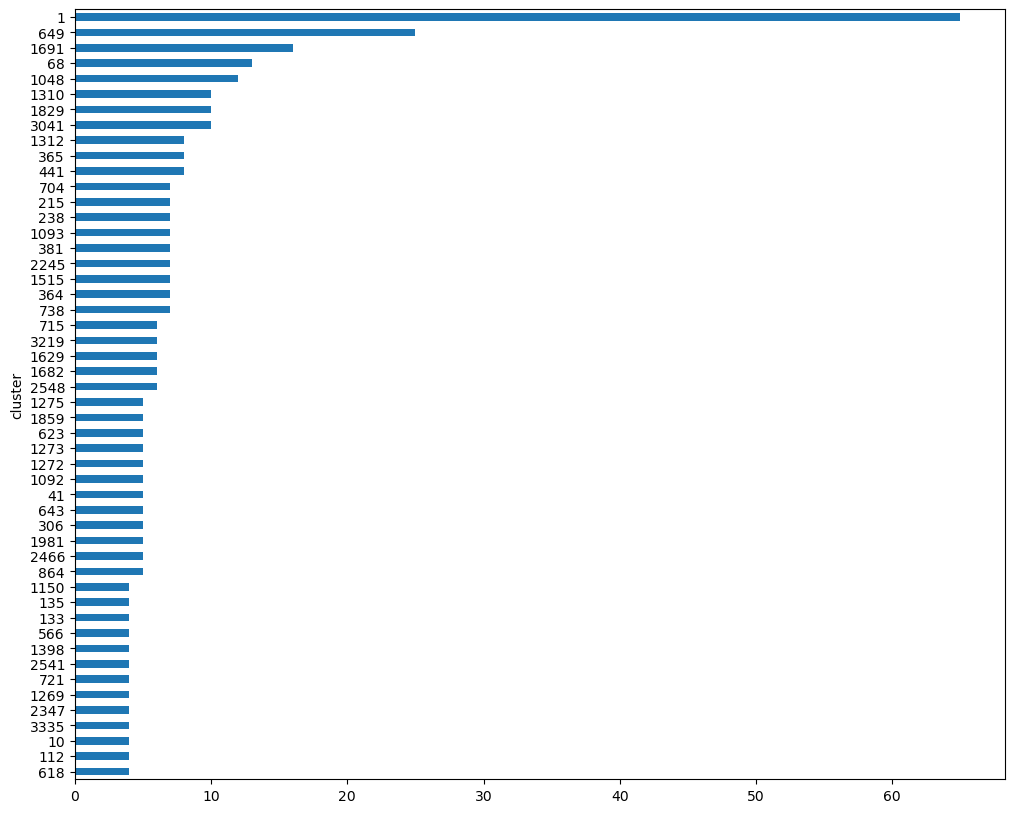

In [13]:
df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [14]:
top_clusters = df['cluster'].value_counts().index.values
top_clusters

array([   1,  649, 1691, ..., 1183, 1184,  304], dtype=int64)

In [15]:
for cluster in top_clusters[0:20]:
    
    print('cluster: {}\n'.format(cluster))
    
    cluster_data = sorted(df[df['cluster']==cluster].head(20)['claim'].values)
    for claim in cluster_data:
        print(claim)
    #print(cluster_data)
    
    print()

cluster: 1

A video report on a mosque shooting in San Diego highlighting the sacrifice of a security guard.
Details about the shooting at the Islamic Center of San Diego.
Discusses the victims of a shooting at a mosque in San Diego.
Identifies the three victims killed in an attack on an Islamic center.
Identifies the victims of a shooting at a mosque in San Diego.
Report on a mosque shooting in San Diego
Teen suspects in San Diego mosque shooting have been identified.
Teen suspects in the San Diego mosque shooting have been identified.
Teen suspects involved in a San Diego mosque shooting have been identified.
Teen suspects involved in a mosque shooting in San Diego have been identified.
The San Diego mosque shooting is linked to Islamophobia.
The shooters of the Islamic Center of San Diego became radicalized after meeting online.
The victims of the San Diego mosque shooting are being honored as heroes for their actions in protecting children.
There are photos and details about a dead

# Good Start

That's a good start, but I want to have three different classes of cluster sizes: A, B, C. A will be biggest, then B, then C will be small clusters.

Big clusters are what everyone is talking about. The big stories.
Medium clusters are stories that are less widely talked about than big clusters.
Small clusters are stories that are talked about by few sources.

In [16]:
# simpler than binning; just gets it done. :)

def classify_cluster(count):

    if count >= 8:
        return 'A'
    elif count >= 4:
        return 'B'
    else:
        return 'C'

In [17]:
cluster_df = pd.DataFrame(df['cluster'].value_counts()).reset_index()

cluster_df['class'] = cluster_df['count'].apply(classify_cluster)

cluster_df

,cluster,count,class
0,1,65,A
1,649,25,A
2,1691,16,A
3,68,13,A
4,1048,12,A
...,...,...,...
3338,1181,1,C
3339,1182,1,C
3340,1183,1,C
3341,1184,1,C


In [18]:
cluster_df['count'].describe()

count    3343.000000
mean        1.190248
std         1.410930
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        65.000000
Name: count, dtype: float64

# Split into Class DFs

Now I want to split this into three DFs and loop through each one so that I can see different size clusters more easily.

In [19]:
class_a_df = cluster_df[cluster_df['class'] == 'A']
class_b_df = cluster_df[cluster_df['class'] == 'B']
class_c_df = cluster_df[cluster_df['class'] == 'C']

## Class A Clusters - Big Clusters; More Chatter

In [20]:
class_df = class_a_df
top_clusters = class_df['cluster'].values

subset_df = df[df['cluster'].isin(top_clusters)].copy()
subset_df['cluster'] = cluster_text(subset_df['claim'], similarity_threshold=0.4) # reducing to capture broader topics

top_clusters = subset_df['cluster'].value_counts().index.values
top_clusters

for cluster in top_clusters:
    
    print('cluster: {}\n'.format(cluster))
    
    cluster_data = sorted(subset_df[subset_df['cluster']==cluster].head(20)['claim'].values)
    for claim in cluster_data:
        print(claim)
    
    print()

cluster: 0

A video report on a mosque shooting in San Diego highlighting the sacrifice of a security guard.
Attack on mosque, police report fatalities in San Diego
Coverage of the San Diego mosque shooting attack.
Coverage of the San Diego mosque shooting incident
Discusses the victims of a shooting at a mosque in San Diego.
Identification of the suspect in the San Diego mosque shooting.
Identifies the victims of a shooting at a mosque in San Diego.
Report on a mosque shooting in San Diego
Report on shooting in a mosque.
Report on the victims of a mosque shooting in San Diego
The victims of the San Diego mosque shooting are being honored as heroes for their actions in protecting children.
Victim of the San Diego mosque shooting
Victims of a mosque shooting in San Diego
Victims of a mosque shooting in San Diego are being honored as heroes.
Victims of a mosque shooting in San Diego are being remembered as heroes
Victims of the San Diego Islamic Center shooting are being recognized as he

## Class B Clusters - Average Sized Clusters;

In [21]:
class_df = class_b_df
top_clusters = class_df['cluster'].values

subset_df = df[df['cluster'].isin(top_clusters)].copy()
subset_df['cluster'] = cluster_text(subset_df['claim'], similarity_threshold=0.4) # reducing to capture broader topics

top_clusters = subset_df['cluster'].value_counts().index.values
top_clusters

for cluster in top_clusters:
    
    print('cluster: {}\n'.format(cluster))
    
    cluster_data = sorted(subset_df[subset_df['cluster']==cluster].head(20)['claim'].values)
    for claim in cluster_data:
        print(claim)
    
    print()

cluster: 10

Crews are maintaining the size of the Sandy fire in Simi Valley while facing potential challenging winds.
Crews are managing the size of the Sandy Fire amidst challenging winds in Simi Valley.
Crews are managing to hold the size of the Sandy Fire overnight in Simi Valley despite the threat of challenging winds.
Crews have maintained the size of the Sandy fire overnight in Simi Valley while facing challenging winds.
Crews have managed to contain the Sandy Fire size overnight in Simi Valley despite challenging winds
Crews have managed to contain the size of the Sandy Fire in Simi Valley overnight despite the threat of challenging winds.
Crews successfully hold the size of a fire overnight in Simi Valley amid challenging winds.

cluster: 7

Afghan Whigs concert in Los Angeles on May 20, 2026, at 8:00 PM
Anri is performing in Los Angeles on May 20, 2026, at 8:00 PM.
Estelle is performing in Los Angeles on May 20, 2026, at 9:30 PM.
Lipphead concert in Los Angeles on May 20, 202

## Class C Clusters - Small Stories; Less Chatter

In [22]:
class_df = class_c_df
top_clusters = class_df['cluster'].values

subset_df = df[df['cluster'].isin(top_clusters)].copy()
subset_df['cluster'] = cluster_text(subset_df['claim'], similarity_threshold=0.4) # reducing to capture broader topics

top_clusters = subset_df['cluster'].value_counts().index.values
top_clusters

for cluster in top_clusters:
    
    print('cluster: {}\n'.format(cluster))
    
    cluster_data = sorted(subset_df[subset_df['cluster']==cluster].head(20)['claim'].values)
    for claim in cluster_data:
        print(claim)
    
    print()

cluster: 511

Colorado Supreme Court orders hospital to resume offering sex change drugs to minors.
Colorado's top court orders a children's hospital to resume gender-affirming care for minors
Court orders children's hospital to resume services
Court ruling on gender-affirming care for children in Colorado

cluster: 210

Angel City FC hosts Kansas City in a busy schedule
Angel City FC vs Kansas City Current match in Los Angeles
Coverage of a match between Angel City FC and Kansas City.
Youth summer camps presented by Angel City FC in Los Angeles

cluster: 1372

Son of Mango founder detained on suspicions.
Son of Mango founder suspected of father's cliff death
Son of mango founder is named a suspect in the father's death.

cluster: 2077

A disturbing real story about siblings who barricaded themselves for 54 days.
Hulu reveals a disturbing situation involving siblings who barricaded themselves in a bedroom for 54 days.
Hulu reveals a disturbing situation involving siblings who livestrea

A Singaporean tourist was rescued by helicopter in South Korea after allegedly entering a restricted area.

cluster: 2172

Farmers are encountering alarming and unusual situations involving boxes of ticks on their properties, suggesting a concerning agricultural issue.

cluster: 2173

A man received a life sentence for attacking a convenience store in Tracy in 2022.

cluster: 2174

A road rage incident in Mastic resulted in a stabbing.

cluster: 2237

SF commission has delayed a vote on smoking ban for outdoor bar patios.

cluster: 2236

A Virginia teacher was shot by a 6-year-old student

cluster: 2235

Home care providers are urging the board of supervisors to increase their pay.

cluster: 2175

Response from black community leaders regarding the arrest of a former Hartford officer.

cluster: 2131

The article lists the nine scariest words according to Zohran Mamdani.

cluster: 2234

Houston area is facing a threat of storms and flooding for several days.

cluster: 2132

High winds h

David Rodriguez's Psycho Night offers a new and bold vision for independent horror.

cluster: 2266

Discussion of security guard's experiences amid London's crime issues.

cluster: 2293

Desantis has expanded Florida's school safety measures to include colleges with a new law.

cluster: 2294

There is a Memorial Day Ceremony at American Legion Post.

cluster: 2295

There is an annual Memorial Day Parade in the Village of Larchmont and Town of Mamaroneck.

cluster: 2296

The finale concert of Bronx Week 2026 attracted large crowds.

cluster: 2322

The costs for the Oklahoma County sheriff's attorney might be paid by taxpayers.

cluster: 2323

A piano recital by Fredericka King is being held.

cluster: 2324

Crime-fighting technology protects Oakland County residents

cluster: 2325

A judge has ordered a mental health evaluation.

cluster: 2326

The imam reports a rise in Islamophobia in the community.

cluster: 2327

Over 30 weapons seized from suspects involved in an attack.

cluster: 

Promotion of a family math application

cluster: 1772

Episode of the show 'Finding Your Roots' titled 'Stranger Than Fiction'

cluster: 1773

PFAS contamination lawsuits in New Mexico

cluster: 1774

Road safety measures in Uttar Pradesh are being strengthened due to recent fatal accidents.

cluster: 1775

The Bombay High Court has permitted a teenage rape survivor to terminate her pregnancy.

cluster: 1776

A 7-year-old boy has died after becoming trapped in a lift.

cluster: 1777

A woman is battling to save her mother’s home

cluster: 1912

W. Kamau Bell is scheduled to perform in San Diego on May 22, 2026.

cluster: 1913

Customers are frustrated due to last-minute tour cancellations by Avg Travels.

cluster: 1916

Alice Kelsey discusses her motivations for serving on the county's community mental health board.

cluster: 2050

A teen was critically injured while safety upgrades in the area are still years away.

cluster: 2052

A breastfeeding mother named Ana Delgado was deported 

Expression of concern or fear regarding a specific situation

cluster: 2499

Teen shootings in Austin linked to stolen guns from a Central Texas gun store

cluster: 2449

Shooting occurs in a park after a parking dispute, injuring several bystanders and leading to two arrests.

cluster: 3002

Open enrollment school choice bill amended to cap number of students

cluster: 3004

Manchester softball league begins its summer season

cluster: 3005

Amendment on pet fostering bill addresses livestock cruelty

cluster: 3006

Berlin police conduct internal review related to murder and homicide cases

cluster: 3007

Menlo College student accused of assaulting a 12-year-old

cluster: 3008

San Bruno massage therapist arrested after a prolonged investigation into sex battery

cluster: 3009

Stage 1 public use fire restrictions have been implemented in Central Oregon.

cluster: 3010

Resources and information about Oregon wildfires.

cluster: 3011

Information about a deadly attack on a San Diego m

...

VCN SDCC Meet-Up in San Diego

cluster: 211

Multiple properties were ransacked in one night in East Leake.

cluster: 212

A list of entertainment activities happening in Eugene this week.

cluster: 213

Two individuals were shot during an attempted burglary in Oak Patch Road.

cluster: 191

L.A. County takes immediate action due to dangerous living conditions reported by Altadena tenants.

cluster: 190

Two fatalities from a big rig crash on Highway 99 near Lodi.

cluster: 189

There is a weekly protest against ICE at the Edward J. Schwartz Federal Building in San Diego.

cluster: 176

A night dedicated to tribute bands in Los Angeles

cluster: 166

The Fox Theater in Banning is celebrating its 98th birthday with a screening of 'Steamboat Bill, Jr.'

cluster: 167

A man in Darien, Illinois, put a gun to a woman's head in her house, and cops were involved.

cluster: 168

A councillor is appealing to locals not to let travelers set up an illegal camp in a country park.

cluster: 169

Re

Mayors detained in a specific case

cluster: 381

News about jury discharge in a trial case

cluster: 382

Lawsuit by officers who defended the Capitol against rioters

cluster: 383

Postponement of case linked to a mass shooting suspect

cluster: 384

Claim that police must act against kidnapping suspects

cluster: 385

Accused of a petrol attack in Pretoria returns to court

cluster: 387

Claim about a teacher's suicide attempt

cluster: 397

Over 600 drivers controlled by the gendarmerie

cluster: 388

Claim about court action against suspect involved in serious crime

cluster: 389

Claim about resolving an issue in Novara regarding a park bench

cluster: 390

Claim about increase in fraudulent calls by fake police

cluster: 391

Claim regarding a court's decision in a secrecy case

cluster: 392

Claim about fighting child abuse using intelligence

cluster: 393

Claim regarding families lacking support in acute care

cluster: 394

Accused of exploiting dozens of women in Zurich

clu

Confirmation of the finding of Yulixa Toloza's body, with details provided.

cluster: 1379

Authorities have found the body in the Yulixa Toloza case.

cluster: 1380

Violence is a national problem for 70% of the population.

cluster: 1381

Historic strike at Samsung, global AI supply chain problems arise.

cluster: 1382

A 15-year-old adolescent dies days after an accident.

cluster: 1383

Worried teachers protest on Wednesday morning.

cluster: 1384

Major update on alleged attacks in Melbourne nightclubs.

cluster: 1385

Heartbreaking update after a teenager was killed in a carpark tragedy.

cluster: 1386

Father of a girl stabbed at a window leads to investigation.

cluster: 1387

Article reports on a shooting incident at Rihanna's house involving Ivanna Lisette Ortiz.

cluster: 1388

There are numerous police cars present, suggesting a significant incident or response.

cluster: 1389

The Vols' bats led them to a victory over South Carolina in the opening round.

cluster: 1390

Ch

A former San Quentin worker has admitted guilt in a drug smuggling investigation.

cluster: 1012

A suspect involved in vandalizing a memorial is being held to face legal charges.

cluster: 1013

The trial for a cold case in Vacaville is currently in the jury's hands for deliberation.

cluster: 990

Concern about deportation of soldier's wife despite ICE release

cluster: 988

An entertainment feature called 'Dancing in the Dark' with Kino is being discussed.

cluster: 1072

There is an increase in requests for help at Caritas, with housing being the primary emergency.

cluster: 987

The interview discusses the significance of changing the name of PCOS to PMOS and its implications.

cluster: 964

Police are searching for suspects involved in a brawl at a Chipotle near Navy Yard.

cluster: 965

A nursery worker has been reported for pinching and kicking children.

cluster: 966

Detroit youth charged in a shooting during a downtown teen takeover

cluster: 967

Rashee Rice, Chiefs wide re

Trump is attempting to conceal the conditions of immigrant detention, with prisoners reporting torture.

cluster: 1198

Discussion on efforts to protect Sag Harbor from national chain establishments

cluster: 1199

Coverage of the Global Sumud Flotilla being obstructed

cluster: 1200

Warning about the risks of buying vehicles with only a STNK (vehicle registration document)

cluster: 1201

A second detainee has died at Rikers Island in less than 24 hours.

cluster: 1229

Parents advocating for the return of primary school

cluster: 1230

Parents opposing no homework policies

cluster: 1231

Tour of MMC Studios focusing on TV production and behind-the-scenes access.

cluster: 1232

Discovery Zone performing at Stone Circle Theatre

cluster: 1262

Unexpected Ebola outbreak threatens World Cup preparations

cluster: 1264

Henar Álvarez criticizes aesthetic pressure on society

cluster: 1265

Discussion on a topic related to Spain

cluster: 1266

News focused on Extremadura, Spain

cluste

In [23]:
# All paying readers who have API access can do this.
# If you do not have API access and would like to pay for it, email me at info@verdantintel.com